# Factor Analysis: A Short Tutorial

**Author:** Taylan Unal  
**Course:** MCDD Module II, Molecular Phenotypic Screening  

## What is this about?

Imagine you measure the expression of 18 genes across 200 cell samples. You notice that some genes always seem to go up or down together. That's not a coincidence , they're being driven by the same underlying biological process, like an active signaling pathway.

Factor analysis is a way to find those hidden drivers. Instead of working with 18 correlated gene measurements, you end up with a small number of interpretable factors that explain most of what's going on. This tutorial walks through the idea and shows how it works on a gene expression example.

## What is Factor Analysis?

The core idea is simple: if many variables move together, maybe there's something hidden causing that. Factor analysis tries to find those hidden things, which we call **latent factors**.

Think of it like this , you measure six genes and they all go up together whenever a cell is inflamed. You could say: instead of tracking six numbers, let's just track one thing: "how inflamed is this cell?" That one thing is a latent factor.

The model assumes each observed variable is a mix of a few latent factors plus some noise specific to that variable:

```
observed gene expression = weighted sum of latent factors + gene-specific noise
```

The weights are called **loadings** , they tell you how strongly each gene is tied to each factor. The goal is to find the smallest number of factors that explains most of the shared variation in the data.

## The Math (briefly)

For a single sample, let $\mathbf{x}$ be the vector of observed gene expressions. The factor model says:

$$\mathbf{x} = \boldsymbol{\mu} + \mathbf{L}\mathbf{f} + \boldsymbol{\epsilon}$$

where $\mathbf{L}$ is the loading matrix, $\mathbf{f}$ are the latent factor scores, and $\boldsymbol{\epsilon}$ is gene-specific noise.

The key thing is that $\boldsymbol{\epsilon}$ is *per-variable* noise , each gene has its own unexplained residual. This is what separates factor analysis from PCA.

The **communality** of a gene tells you how much of its variance is explained by all factors combined. High communality means the gene is well-captured; low means it's mostly noise.

## Factor Analysis vs. PCA

People mix these up all the time. Both reduce dimensions, but the goal is different.

| | PCA | Factor Analysis |
|---|---|---|
| Goal | Explain total variance | Explain shared variance only |
| Output | Principal components | Latent factors |
| Noise | Ignored | Modeled explicitly per variable |
| Rotation | Not standard | Varimax rotation for cleaner interpretation |
| Best for | Compression, visualization | Finding interpretable latent structure |

In short: PCA tells you *how* samples differ. Factor analysis tells you *why* , what underlying processes are driving those differences.

## Use Case: Gene Expression Under Drug Treatment

In phenotypic drug discovery, one approach is to measure which genes go up or down when cells are treated with a compound. The idea is that drugs with similar mechanisms produce similar gene expression patterns.

We simulate a small version of this: 200 drug-treated cell samples, each profiled for 18 genes. The data was generated by three hidden biological processes:

- **Inflammatory response:** *IL6, TNF, CXCL8, CCL2, PTGS2, NFKB1*
- **Cell cycle / proliferation:** *MKI67, CCNB1, CDK1, PCNA, E2F1, MCM2*
- **Oxidative stress / apoptosis:** *HMOX1, SOD2, TP53, BAX, CASP3, NRF2*

The algorithm doesn't know this. We want to see if factor analysis can recover it just from the data.

## Let's run it

In [1]:
# Install required library if not already available
# factor_analyzer provides a proper FA implementation with rotation support
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'factor_analyzer', '--quiet'], check=False)


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip3.9 install --upgrade pip


CompletedProcess(args=['/Library/Frameworks/Python.framework/Versions/3.9/bin/python3', '-m', 'pip', 'install', 'factor_analyzer', '--quiet'], returncode=0)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries loaded successfully.')

Libraries loaded successfully.


### Simulating the data

In [3]:
# ─── Gene names (18 genes, 3 groups of 6) ───────────────────────────────────
genes = [
    # Inflammatory Response (Factor 1)
    'IL6', 'TNF', 'CXCL8', 'CCL2', 'PTGS2', 'NFKB1',
    # Cell Cycle / Proliferation (Factor 2)
    'MKI67', 'CCNB1', 'CDK1', 'PCNA', 'E2F1', 'MCM2',
    # Oxidative Stress / Apoptosis (Factor 3)
    'HMOX1', 'SOD2', 'TP53', 'BAX', 'CASP3', 'NRF2'
]
n_samples = 200
n_genes   = len(genes)   # 18
n_factors = 3

# ─── True latent factor scores for each sample ──────────────────────────────
# Each column is a factor; samples vary along each factor independently
F_true = np.random.randn(n_samples, n_factors)

# ─── True loading matrix ────────────────────────────────────────────────────
# Each gene loads strongly on exactly one factor (simple structure)
L_true = np.zeros((n_genes, n_factors))
L_true[0:6,  0] = np.array([0.85, 0.80, 0.78, 0.82, 0.75, 0.88])  # Factor 1
L_true[6:12, 1] = np.array([0.90, 0.83, 0.87, 0.79, 0.81, 0.86])  # Factor 2
L_true[12:18,2] = np.array([0.77, 0.80, 0.83, 0.79, 0.84, 0.78])  # Factor 3

# ─── Unique noise (gene-specific, not shared) ───────────────────────────────
noise_sd = 0.45
epsilon = np.random.randn(n_samples, n_genes) * noise_sd

# ─── Observed data: X = F * L^T + epsilon ───────────────────────────────────
X_raw = F_true @ L_true.T + epsilon

df = pd.DataFrame(X_raw, columns=genes)
print(f'Dataset shape: {df.shape}  ({n_samples} samples × {n_genes} genes)')
df.head()

Dataset shape: (200, 18)  (200 samples × 18 genes)


,IL6,TNF,CXCL8,CCL2,PTGS2,NFKB1,MKI67,CCNB1,CDK1,PCNA,E2F1,MCM2,HMOX1,SOD2,TP53,BAX,CASP3,NRF2
0,0.762852,-0.017603,0.778760,1.017343,0.558581,1.281667,-0.472643,-0.674854,-0.920714,0.563991,0.182470,-0.143920,0.624706,0.011681,1.638170,0.569823,0.593286,0.831792
1,1.511030,1.319172,0.832250,1.461045,1.989183,1.945705,0.506196,-0.424394,-0.649036,-0.241585,-0.164588,0.291014,-0.941895,0.500988,-0.265437,-0.377065,-0.652122,-0.927312
2,1.712758,1.296363,0.651304,0.712169,1.033306,2.140767,0.573875,-0.039444,0.557084,0.483548,-0.591977,0.635561,-0.465416,-0.062287,0.442367,0.136069,-0.515358,-0.864127
3,1.619188,0.460696,0.429465,0.434043,0.496058,0.412491,-0.675224,-0.630723,-0.417912,-0.610641,-0.696149,-0.350646,-0.473352,0.304213,-1.579492,0.123252,0.169525,-1.296295
4,0.051459,0.026421,-0.444650,-0.151608,-0.318287,1.001448,-1.300897,-1.015823,-1.339801,-2.019565,-1.785791,-1.425202,-1.878144,-1.059085,-1.539828,-1.531354,-1.128999,-1.145517


### Checking the correlation structure

First, let's just look at the gene-gene correlations. If genes within the same pathway are correlated and genes across pathways are not, factor analysis should pick that up easily.

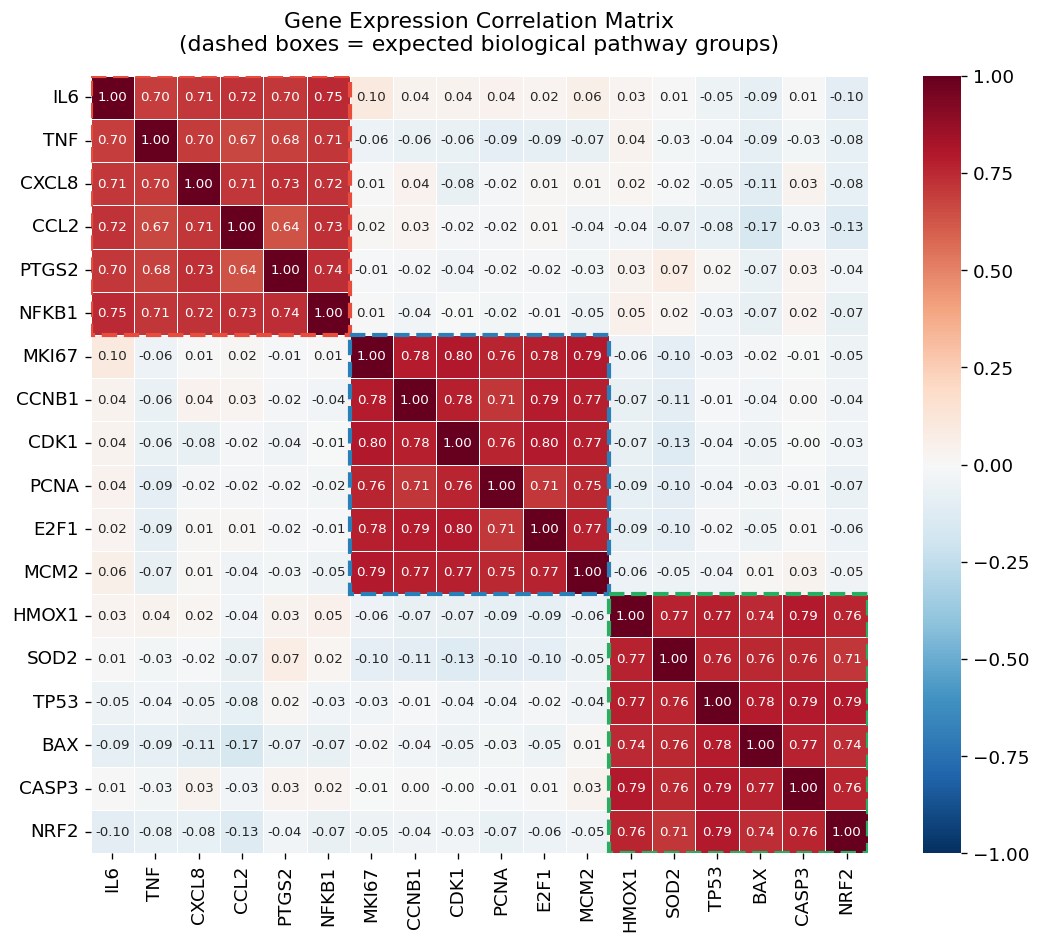

Observation: genes within the same pathway are highly correlated;
genes in different pathways are essentially uncorrelated.


In [4]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax
)

# Draw boxes around the three gene groups
for i, color in enumerate(['#e74c3c', '#2980b9', '#27ae60']):
    rect = plt.Rectangle((i*6, i*6), 6, 6, fill=False,
                          edgecolor=color, lw=2.5, linestyle='--')
    ax.add_patch(rect)

ax.set_title('Gene Expression Correlation Matrix\n'
             '(dashed boxes = expected biological pathway groups)', pad=15)
plt.tight_layout()
plt.show()

print('Observation: genes within the same pathway are highly correlated;')
print('genes in different pathways are essentially uncorrelated.')

### Is the data suitable for factor analysis?

Two quick checks before fitting:

- **Bartlett's test** checks whether there are any meaningful correlations at all. We need p < 0.05.
- **KMO** measures how much of the variance is shared vs. unique. Above 0.6 is acceptable, above 0.8 is good.

In [5]:
chi2, p_val = calculate_bartlett_sphericity(df)
kmo_per_var, kmo_model = calculate_kmo(df)

print('=== Suitability for Factor Analysis ===')
print(f'Bartlett\'s Test of Sphericity:')
print(f'  χ² = {chi2:.2f},  p-value = {p_val:.2e}')
print(f'  → p < 0.05: {p_val < 0.05}  ✓ (significant correlation structure exists)')
print()
print(f'Kaiser-Meyer-Olkin (KMO) Measure:')
print(f'  Overall KMO = {kmo_model:.3f}')
if kmo_model >= 0.8:
    print('  → Excellent: FA is highly appropriate.')
elif kmo_model >= 0.6:
    print('  → Acceptable: FA is appropriate.')
else:
    print('  → Poor: reconsider whether FA is suitable.')

=== Suitability for Factor Analysis ===
Bartlett's Test of Sphericity:
  χ² = 3244.00,  p-value = 0.00e+00
  → p < 0.05: True  ✓ (significant correlation structure exists)

Kaiser-Meyer-Olkin (KMO) Measure:
  Overall KMO = 0.914
  → Excellent: FA is highly appropriate.


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


### How many factors?

The scree plot shows eigenvalues in descending order. The **Kaiser rule** says keep factors with eigenvalue > 1. The elbow point, where the curve flattens, is another useful guide.

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


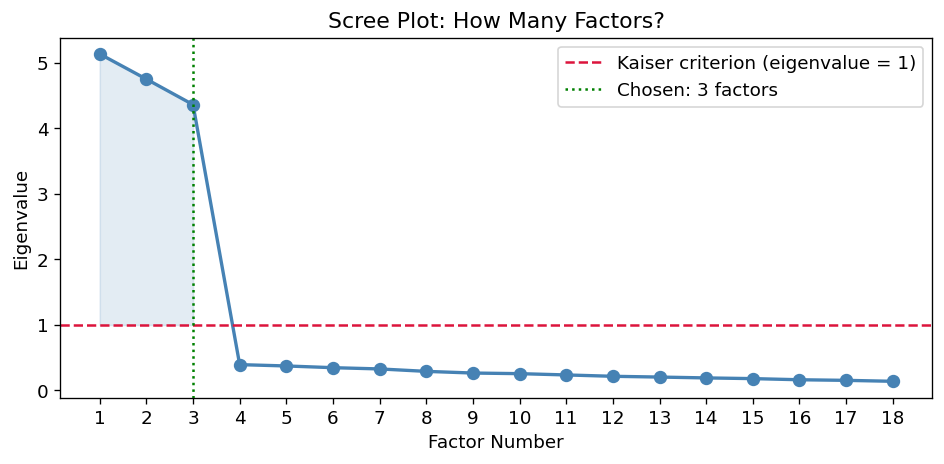

Eigenvalues: ['5.14', '4.75', '4.36', '0.39', '0.37', '0.35', '0.33', '0.29'] ...

Factors with eigenvalue > 1: 3
→ Both Kaiser criterion and the elbow suggest k = 3 factors.


In [6]:
# Fit FA with maximum possible factors to get eigenvalues
fa_scree = FactorAnalyzer(n_factors=n_genes, rotation=None)
fa_scree.fit(df)
eigenvalues, _ = fa_scree.get_eigenvalues()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(eigenvalues) + 1), eigenvalues,
        'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(y=1, color='crimson', linestyle='--', linewidth=1.5,
           label='Kaiser criterion (eigenvalue = 1)')
ax.axvline(x=3, color='green', linestyle=':', linewidth=1.5,
           label='Chosen: 3 factors')
ax.fill_between(range(1, 5), eigenvalues[:4], 1,
                where=[e > 1 for e in eigenvalues[:4]],
                alpha=0.15, color='steelblue')
ax.set_xlabel('Factor Number')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot: How Many Factors?')
ax.legend()
ax.set_xticks(range(1, len(eigenvalues) + 1))
plt.tight_layout()
plt.show()

print('Eigenvalues:', [f'{e:.2f}' for e in eigenvalues[:8]], '...')
print(f'\nFactors with eigenvalue > 1: {sum(e > 1 for e in eigenvalues)}')
print('→ Both Kaiser criterion and the elbow suggest k = 3 factors.')

### Fitting the model

We fit factor analysis with 3 factors and **Varimax rotation**. Rotation reshuffles the loadings so each gene loads heavily on just one factor , this makes the results much easier to read.

In [7]:
# Fit FA with 3 factors and Varimax rotation
# Varimax maximises variance of squared loadings per factor
# → each gene loads high on one factor and near-zero on others (simple structure)
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df)

# Extract results
loadings = pd.DataFrame(
    fa.loadings_,
    index=genes,
    columns=['Factor 1', 'Factor 2', 'Factor 3']
)

# Variance explained
variance = fa.get_factor_variance()
variance_df = pd.DataFrame(
    variance,
    index=['SS Loadings', 'Proportion Variance', 'Cumulative Variance'],
    columns=['Factor 1', 'Factor 2', 'Factor 3']
)

print('=== Variance Explained ===')
print(variance_df.round(3))
print(f"\nTotal variance explained: {variance_df.loc['Cumulative Variance', 'Factor 3']:.1%}")

=== Variance Explained ===
                     Factor 1  Factor 2  Factor 3
SS Loadings             4.630     4.600     4.273
Proportion Variance     0.257     0.256     0.237
Cumulative Variance     0.257     0.513     0.750

Total variance explained: 75.0%


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Interpreting the Results

### Loading matrix

The loading matrix shows how strongly each gene is linked to each factor. After Varimax rotation, we expect a clean pattern: high loading on one factor, close to zero on the others.

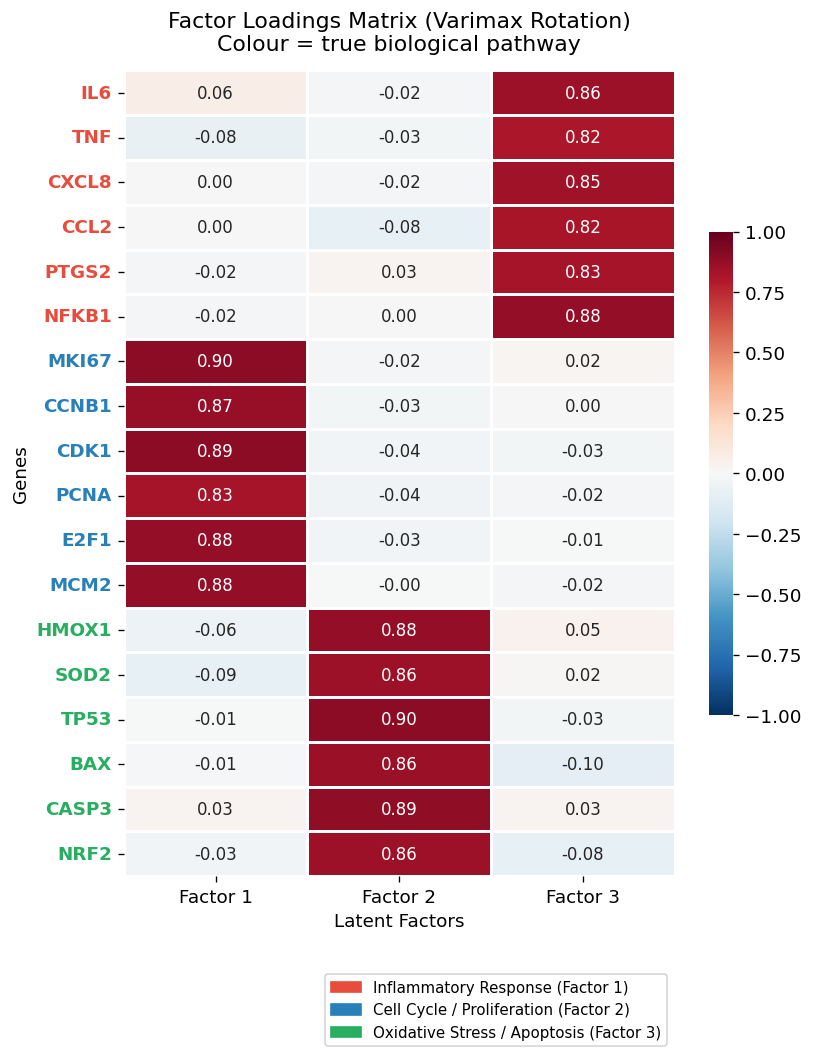

In [8]:
# Colour-code genes by their true biological group
gene_colors = (['#e74c3c'] * 6 +   # Factor 1: Inflammatory
               ['#2980b9'] * 6 +   # Factor 2: Cell Cycle
               ['#27ae60'] * 6)    # Factor 3: Oxidative Stress

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(
    loadings,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.8, square=False, ax=ax,
    cbar_kws={'shrink': 0.6}
)

# Colour y-tick labels by biological group
for label, color in zip(ax.get_yticklabels(), gene_colors):
    label.set_color(color)
    label.set_fontweight('bold')

ax.set_title('Factor Loadings Matrix (Varimax Rotation)\n'
             'Colour = true biological pathway', pad=12)
ax.set_xlabel('Latent Factors')
ax.set_ylabel('Genes')

patches = [
    mpatches.Patch(color='#e74c3c', label='Inflammatory Response (Factor 1)'),
    mpatches.Patch(color='#2980b9', label='Cell Cycle / Proliferation (Factor 2)'),
    mpatches.Patch(color='#27ae60', label='Oxidative Stress / Apoptosis (Factor 3)'),
]
ax.legend(handles=patches, loc='lower right',
          bbox_to_anchor=(1.0, -0.22), fontsize=9)
plt.tight_layout()
plt.show()

### Factor scores

Each sample gets a score for each factor , how much that biological process was active in that treatment. Here we plot samples in the factor space.

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


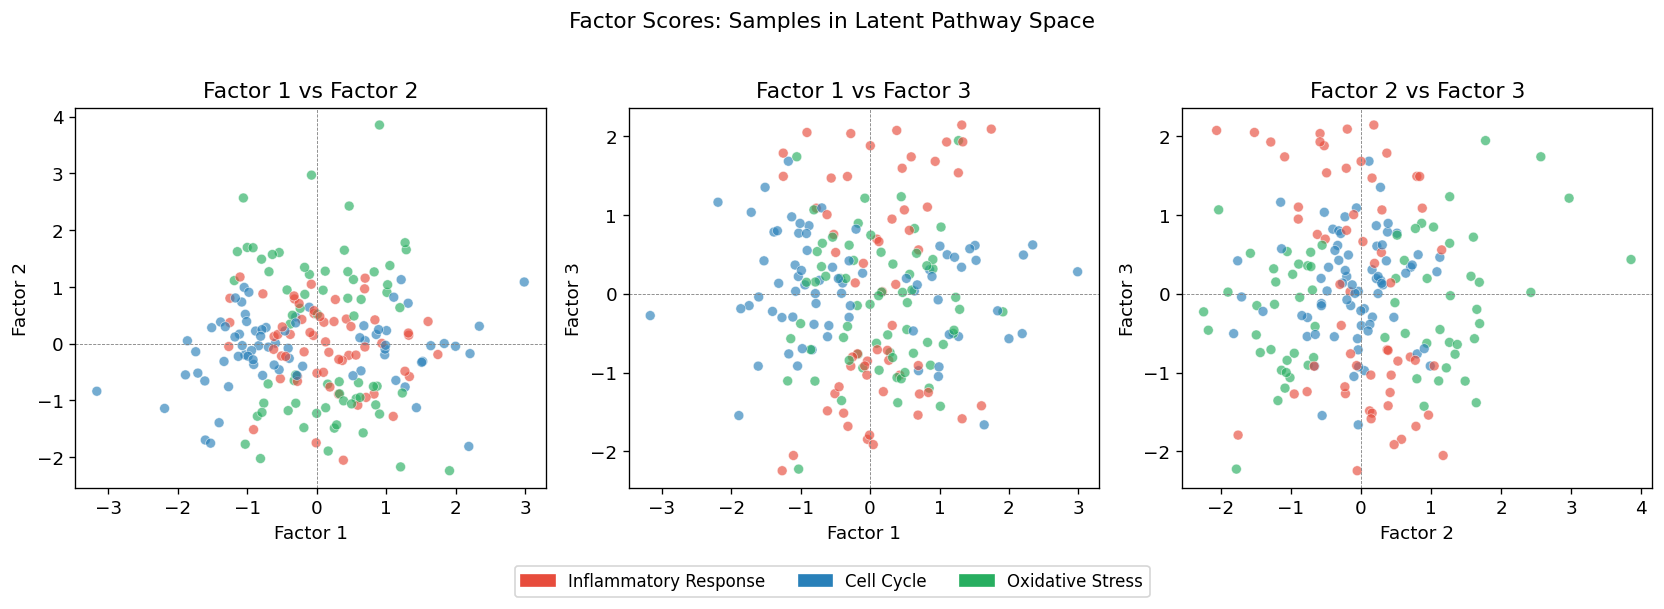

In [9]:
scores = fa.transform(df)
scores_df = pd.DataFrame(scores, columns=['Factor 1', 'Factor 2', 'Factor 3'])

# Assign a dominant pathway label to each sample based on true factor scores
dominant = np.argmax(np.abs(F_true), axis=1)
pathway_labels = {0: 'Inflammatory', 1: 'Cell Cycle', 2: 'Oxidative Stress'}
colors_map = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
sample_colors = [colors_map[d] for d in dominant]
sample_labels = [pathway_labels[d] for d in dominant]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = [('Factor 1', 'Factor 2'),
               ('Factor 1', 'Factor 3'),
               ('Factor 2', 'Factor 3')]

for ax, (i, j), (xl, yl) in zip(axes, pairs, pair_labels):
    ax.scatter(scores_df.iloc[:, i], scores_df.iloc[:, j],
               c=sample_colors, alpha=0.65, s=35, edgecolors='white', linewidth=0.4)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')

patches = [
    mpatches.Patch(color='#e74c3c', label='Inflammatory Response'),
    mpatches.Patch(color='#2980b9', label='Cell Cycle'),
    mpatches.Patch(color='#27ae60', label='Oxidative Stress'),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=10)
fig.suptitle('Factor Scores: Samples in Latent Pathway Space', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Communalities

Communality tells us what fraction of each gene's variance is explained by the factors. A gene with high communality is well-captured by the model; low communality means it's mostly noise that the factors didn't pick up.

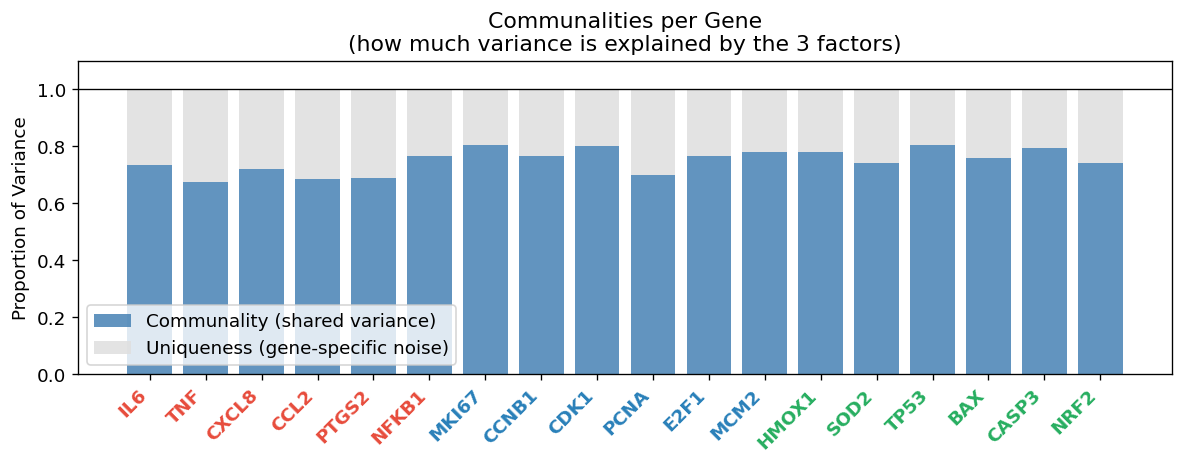

       Communality  Uniqueness
IL6          0.736       0.264
TNF          0.674       0.326
CXCL8        0.722       0.278
CCL2         0.684       0.316
PTGS2        0.688       0.312
NFKB1        0.767       0.233
MKI67        0.804       0.196
CCNB1        0.765       0.235
CDK1         0.800       0.200
PCNA         0.698       0.302
E2F1         0.768       0.232
MCM2         0.779       0.221
HMOX1        0.781       0.219
SOD2         0.741       0.259
TP53         0.805       0.195
BAX          0.757       0.243
CASP3        0.792       0.208
NRF2         0.742       0.258


In [10]:
communalities = pd.Series(fa.get_communalities(), index=genes, name='Communality')
uniqueness    = pd.Series(fa.get_uniquenesses(),  index=genes, name='Uniqueness')

comm_df = pd.concat([communalities, uniqueness], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(genes))
bars_c = ax.bar(x, comm_df['Communality'], color='steelblue',
                alpha=0.85, label='Communality (shared variance)')
bars_u = ax.bar(x, comm_df['Uniqueness'], bottom=comm_df['Communality'],
                color='#e0e0e0', alpha=0.9, label='Uniqueness (gene-specific noise)')

# Colour x-labels by pathway
ax.set_xticks(x)
ax.set_xticklabels(genes, rotation=45, ha='right')
for label, color in zip(ax.get_xticklabels(), gene_colors):
    label.set_color(color)
    label.set_fontweight('bold')

ax.axhline(1.0, color='black', lw=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Proportion of Variance')
ax.set_title('Communalities per Gene\n(how much variance is explained by the 3 factors)')
ax.legend()
plt.tight_layout()
plt.show()

print(comm_df.round(3))

### Validation: did we recover the true structure?

Since we generated the data ourselves, we can directly check whether factor analysis recovered the loadings we used in the simulation.

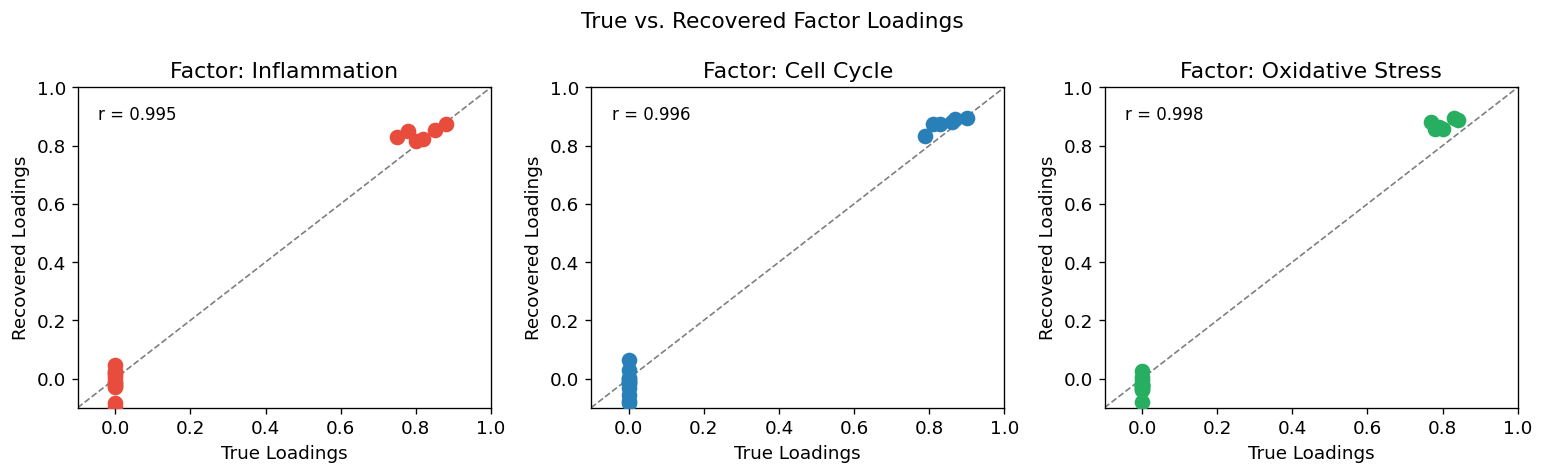


Conclusion: Factor analysis successfully recovered the three biological
pathways embedded in the simulated gene expression data.


In [11]:
# Align recovered factors with true factors (factor ordering may differ)
# We match by maximum absolute correlation of loadings columns
true_L = pd.DataFrame(L_true, index=genes,
                       columns=['True F1 (Inflammation)',
                                'True F2 (Cell Cycle)',
                                'True F3 (Oxidative Stress)'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
factor_names = ['Inflammation', 'Cell Cycle', 'Oxidative Stress']

# Map recovered factors to true factors by correlation
corr_matrix = np.abs(np.corrcoef(L_true.T, fa.loadings_.T)[:3, 3:])
col_order = np.argmax(corr_matrix, axis=1)

for ax, true_col, rec_col, name in zip(axes,
                                        range(3), col_order, factor_names):
    true_vals = L_true[:, true_col]
    rec_vals  = fa.loadings_[:, rec_col]
    # Align sign
    if np.corrcoef(true_vals, rec_vals)[0, 1] < 0:
        rec_vals = -rec_vals

    ax.scatter(true_vals, rec_vals, color=list(colors_map.values())[true_col],
               s=70, zorder=3)
    lims = [-0.1, 1.0]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('True Loadings')
    ax.set_ylabel('Recovered Loadings')
    ax.set_title(f'Factor: {name}')

    r = np.corrcoef(true_vals, rec_vals)[0, 1]
    ax.text(0.05, 0.90, f'r = {r:.3f}', transform=ax.transAxes, fontsize=10)

fig.suptitle('True vs. Recovered Factor Loadings', fontsize=13)
plt.tight_layout()
plt.show()

print('\nConclusion: Factor analysis successfully recovered the three biological')
print('pathways embedded in the simulated gene expression data.')

### Which genes define each factor?

Using a loading threshold of 0.4, we can see which genes most strongly define each factor.

In [12]:
# Identify top genes per factor (|loading| > 0.40)
threshold = 0.40
factor_interpretation = {}

# Re-align for display: identify which recovered factor matches each true factor
for i, fname in enumerate(['Factor 1', 'Factor 2', 'Factor 3']):
    top_genes = loadings[fname][loadings[fname].abs() > threshold]
    top_genes = top_genes.sort_values(key=abs, ascending=False)
    factor_interpretation[fname] = top_genes

print('=== Factor Interpretation: Top Genes (|loading| > 0.40) ===\n')
for fname, top in factor_interpretation.items():
    print(f'{fname}:')
    for gene, loading in top.items():
        print(f'  {gene:8s}  loading = {loading:+.3f}')
    print()

=== Factor Interpretation: Top Genes (|loading| > 0.40) ===

Factor 1:
  MKI67     loading = +0.896
  CDK1      loading = +0.893
  MCM2      loading = +0.883
  E2F1      loading = +0.875
  CCNB1     loading = +0.874
  PCNA      loading = +0.834

Factor 2:
  TP53      loading = +0.897
  CASP3     loading = +0.889
  HMOX1     loading = +0.881
  BAX       loading = +0.865
  NRF2      loading = +0.857
  SOD2      loading = +0.856

Factor 3:
  NFKB1     loading = +0.875
  IL6       loading = +0.855
  CXCL8     loading = +0.849
  PTGS2     loading = +0.829
  CCL2      loading = +0.823
  TNF       loading = +0.817



## Wrapping up

Factor analysis took 18 correlated gene expression measurements and boiled them down to 3 interpretable factors , each matching a real biological pathway that was hidden in the data.

The main idea to take away: when many variables move together, it usually means something hidden is driving them. Factor analysis finds that hidden structure, names it, and gives you a compact representation that's much easier to work with than the original raw measurements.

In drug discovery, this matters because gene expression profiles from compound screens can be thousands of dimensions wide. Factor analysis compresses them into a small set of biologically meaningful axes , making it possible to compare compounds, cluster them by mechanism, and spot patterns that would be invisible in the raw data.